# Cls 1. MLP from scratch

## Plan

- [x] MLP (multi-layer perceptron) forward path in numpy 
- [x] How to calculate partial derivatives of loss function with respect to MLP parameters  
- [x] Implement each layer of MLP with forward and backward pass 
- [x] Combine layers into the model, implement *backpropogation* and gradient descent
- [x] Inspect & prepare data for training
- [x] Train the model and inspect results

Whiteboard: https://excalidraw.com/#json=tCRXHAbjMoPTTXKbUw13K,juvUKf11i0M2PBJ38klTTg

## MLP forward pass in numpy

In [1]:
import numpy as np
rng = np.random.default_rng(seed=42)

In [2]:
p = 10
x = rng.normal(size=(p, ))

In [3]:
h = 15
weight = rng.normal(size=(p, h)) 
bias = rng.normal(size=(h))

def relu(x):
    out = x.copy()
    out[x < 0] = 0
    return out

In [4]:
# linear layer
out = relu(x @ weight + bias)
out

array([1.9606884 , 2.56712547, 4.5097791 , 0.        , 0.51893669,
       0.        , 3.46746224, 2.48984074, 0.96036865, 2.33584664,
       0.        , 2.98979953, 0.76730624, 0.81491956, 2.22094442])

## Backpropagation for MLP

$$\frac{\partial L}{\partial w_{ij}^k} = \left( \frac{\partial L}{\partial y^k} \right)^T \cdot \frac{\partial y^k}{\partial w_{ij}^k}$$

$$\frac{\partial L}{\partial y^{k-1}} = \left( \frac{\partial L}{\partial y^k} \right)^T \cdot \frac{\partial y^k}{\partial y^{k-1}}$$

## MLP layers

In [58]:
import abc

class Layer(abc.ABC):
    def __init__(self):
        self.x_cache = None

    @abc.abstractmethod
    def forward(self, x):
        pass

    @abc.abstractmethod
    def backward(self, grad_upstream):
        pass

    def __call__(self, x):
        return self.forward(x)

In [59]:
class Linear(Layer):
    def __init__(self, n_in, n_out, weight_scale=None):
        self.n_in = n_in
        self.n_out = n_out

        if weight_scale is None:
            weight_scale = np.sqrt(2 / n_in)

        self.weight = rng.normal(0, weight_scale, size=(n_in, n_out))
        self.bias = np.zeros(n_out)

        self.dw = None
        self.db = None

    def forward(self, x):
        self.x_cache = x

        out = x @ self.weight + self.bias

        return out

    def backward(self, grad_upstream):
        x = self.x_cache

        self.dw = x[:, :, None] * grad_upstream[:, None, :]
        self.db = grad_upstream
        dx = grad_upstream @ self.weight.T

        return dx

In [60]:
# ReLU(x) = max(0, x) 

class ReLU(Layer):
    def forward(self, x):
        self.x_cache = x

        return np.maximum(x, 0)

    def backward(self, grad_upstream):
        x = self.x_cache
        dx = grad_upstream * (x > 0)

        return dx

In [61]:
class Sigm(Layer):
    def forward(self, x):
        self.x_cache = x
        self.sigm_x = 1 / (1 + np.exp(-x))

        return self.sigm_x

    def backward(self, grad_upstream):
        sigm = self.sigm_x
        dx = grad_upstream * sigm * (1 - sigm)

        return dx

## Model & training infra

In [63]:
class MLP(Layer):
    def __init__(self, d_in, d_out, d_hidden, depth=8):
        self.layers = [Linear(d_in, d_hidden), ReLU()]

        for _ in range(depth-1):
            self.layers.extend([
                Linear(d_hidden, d_hidden),
                ReLU()
            ])

        self.layers.extend([Linear(d_hidden, d_out), Sigm()])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)

        return x

    def backward(self, grad_upstream):
        grad = grad_upstream

        for layer in self.layers[::-1]:
            grad = layer.backward(grad)

        return grad

    def optim_step(self, lr):
        for layer in self.layers:
            if isinstance(layer, Linear):
                layer.weight -= lr * layer.dw.mean(axis=0)
                layer.bias -= lr * layer.db.mean(axis=0)

In [64]:
def bce_loss(y, y_target, eps=1e-10):
    y = np.clip(y, eps, 1-eps)
    loss = - y_target * np.log(y) - (1 - y_target) * np.log(1 - y)
    dldy = - y_target / y + (1 - y_target) / (1 - y)

    return loss, dldy

## Data & training

In [65]:
from tqdm.auto import tqdm 
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("data/cls1/points.csv", sep=' ', names=['x', 'y', 'cls'])

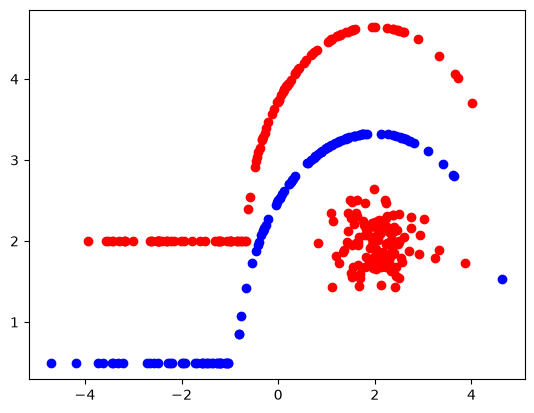

In [66]:
plt.scatter(*data[data['cls'] == 0][['x', 'y']].values.T, c='blue')
plt.scatter(*data[data['cls'] == 1][['x', 'y']].values.T, c='red')

In [67]:
n_steps = 1000
lr = 1e-1

model = MLP(2, 1, 10, 8)
x = data[['x', 'y']].values
y_target = data['cls'].values[:, None]

In [68]:
loss_history = []

for step in tqdm(range(n_steps)):
    y = model(x)
    loss, dldy = bce_loss(y, y_target)
    loss_history.append(loss.mean())

    model.backward(dldy)
    model.optim_step(lr=lr)

  0%|          | 0/1000 [00:00<?, ?it/s]

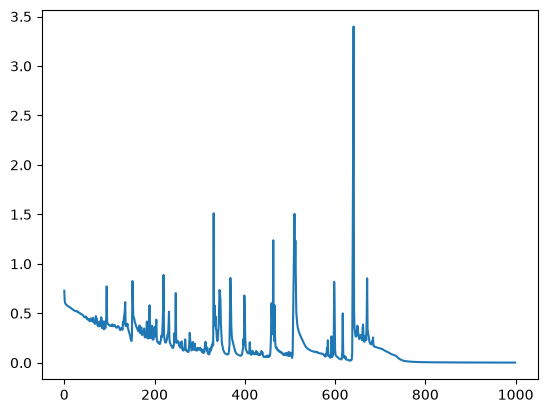

In [69]:
plt.plot(loss_history)

In [70]:
y = model(x)

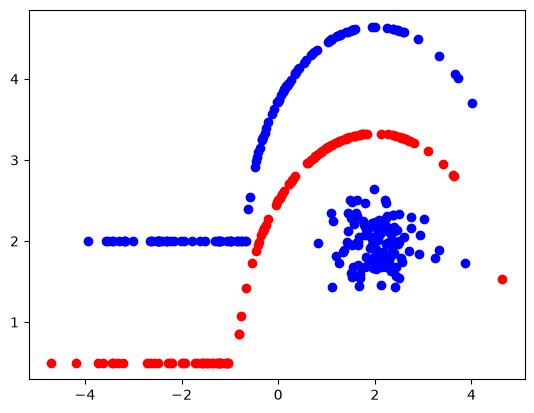

In [71]:
plt.scatter(*data[y > 0.5][['x', 'y']].values.T, c='blue')
plt.scatter(*data[y < 0.5][['x', 'y']].values.T, c='red')